In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from pandas.plotting import table

%matplotlib inline
plt.rcParams["figure.figsize"] = [12,8]

np.random.seed(42)

In [26]:
import warnings
warnings.filterwarnings("ignore")

# Логистическая регрессия

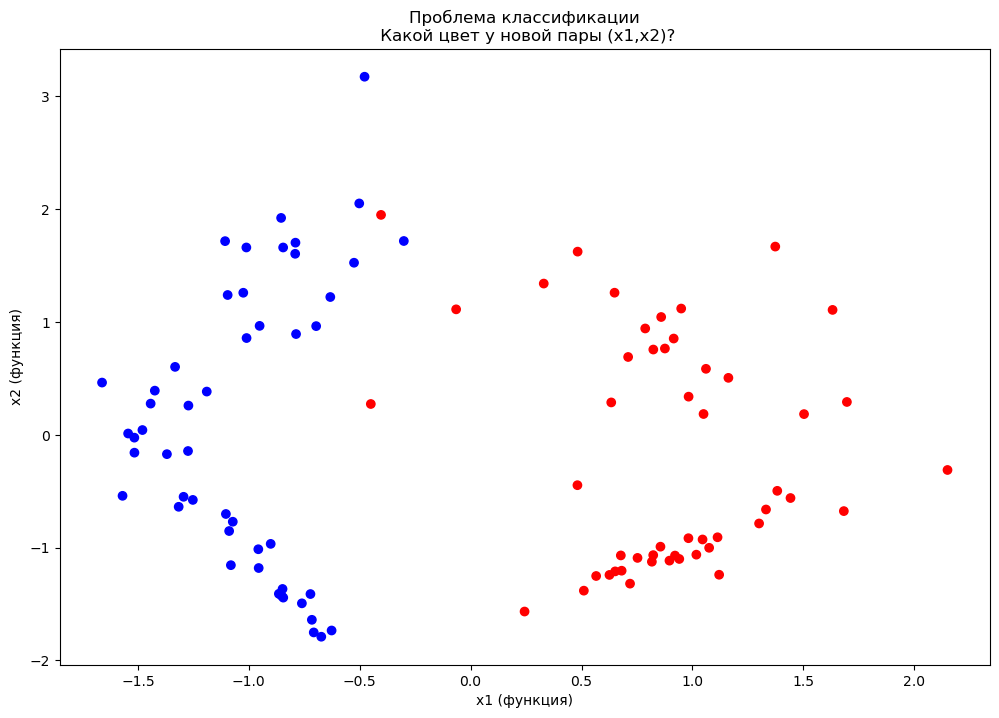

In [27]:
X, y = datasets.make_classification(n_features=2, n_informative=2, n_redundant=0, n_repeated=0, random_state=1)

colors = ['red' if y_i else 'blue' for y_i in y]
plt.scatter(X[:, 0], X[:, 1], c=colors)
plt.title("Проблема классификации\n Какой цвет у новой пары (x1,x2)?")
plt.xlabel("x1 (функция)")
plt.ylabel("x2 (функция)");

# Линейный классификатор

Построим случайную прямую. Насколько хорошо она описывает данные?

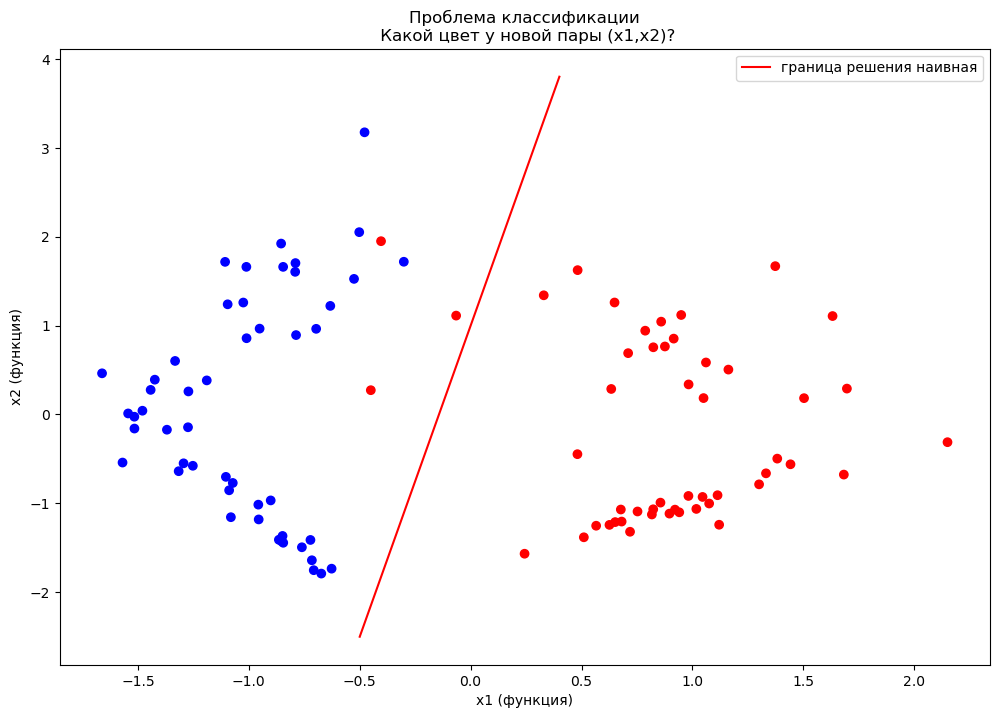

In [28]:
x_naive = np.arange(-0.5, 0.5, 0.1)
y_naive = 7 * x_naive + 1

plt.scatter(X[:, 0], X[:, 1], c=colors)
plt.title("Проблема классификации\n Какой цвет у новой пары (x1,x2)?")
plt.xlabel("x1 (функция)")
plt.ylabel("x2 (функция)")
plt.plot(x_naive, y_naive, c='red', label="граница решения наивная")
plt.legend()

## Как принимается решение

Простой вариант - узнать, с какой стороны от гиперплоскости находится точка

$$\hat{y} = \text{sign}(x\theta)$$


In [29]:
w = np.array([7, -1, 1]) # Ax + By + C = 0

# Замечание: расстояние от точки (x0, y0) до прямой Ax + By + C это abs(Ax0 + By0 + C) / sqrt(A^2 + B^2)

def predict(x, w):
    return np.sign(x.dot(w))

x_pred = np.hstack([np.random.rand(10, 2) * 4 - 2, np.ones(10).reshape(-1, 1)])
y_pred = predict(x_pred, w)

print(x_pred.shape)
print(y_pred.shape)

(10, 3)
(10,)


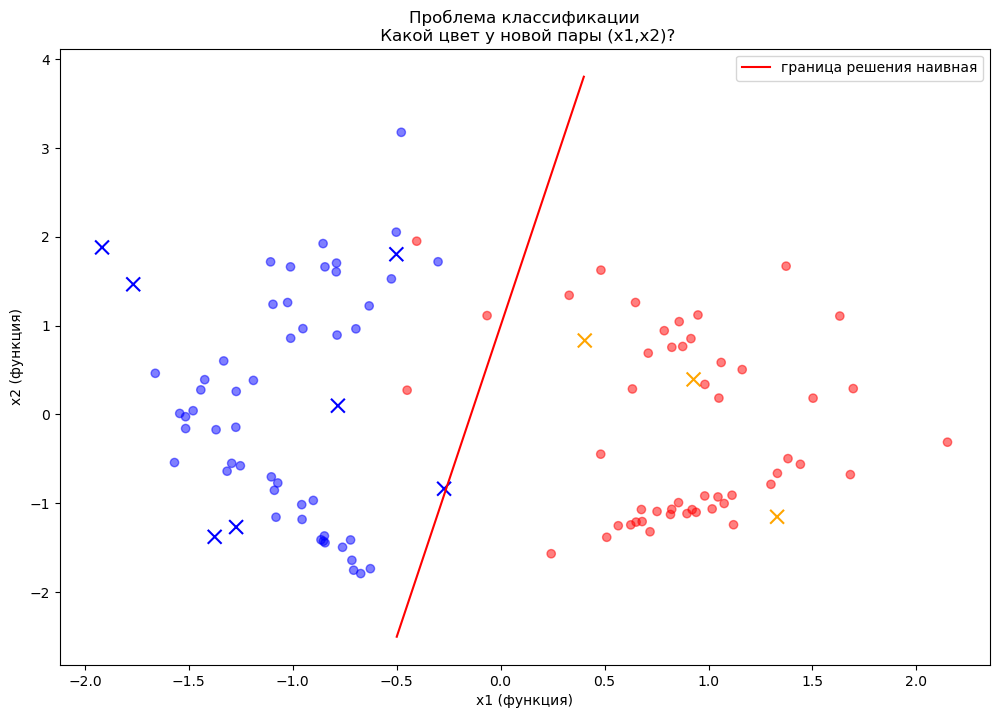

In [30]:
x_naive = np.arange(-0.5, 0.5, 0.1)
# naive boundary
y_naive = 7 * x_naive + 1

plt.scatter(x_pred[:, 0], x_pred[:, 1], c=['orange' if y_i > 0 else 'blue' for y_i in y_pred], marker='x', s=100)
plt.title("Проблема классификации\n Какой цвет у новой пары (x1,x2)?")
plt.xlabel("x1 (функция)")
plt.ylabel("x2 (функция)")
plt.scatter(X[:, 0], X[:, 1], c=colors, alpha=0.5)
plt.plot(x_naive, y_naive, c='red', label="граница решения наивная")
plt.legend()

## Как оценить результат - простой вариант

Отступ (margin) - величина $M_i = y_i \cdot x_i\theta$ (для $y = 1$ или $y = -1$), где $x_i$ - элемент обучающей выборки, $y_i$ - его класс

$$M_i \leq 0 \Rightarrow y_i \neq \hat{y_i}$$
$$M_i > 0 \Rightarrow y_i = \hat{y_i}$$

Функция потерь zero-one loss:
$$ f(x) = \begin{cases}
      1, & \text{если}\space \hat{y} \neq y, \\
      0, & \text{если}\space \hat{y} = y
    \end{cases}
$$ 

Эмпирический риск:
$$Q(\theta, x) = \frac{1}{n} \sum_{i=1}^{n} f(x) = \frac{1}{n} \sum_{i=1}^{n}[M_i < 0]$$

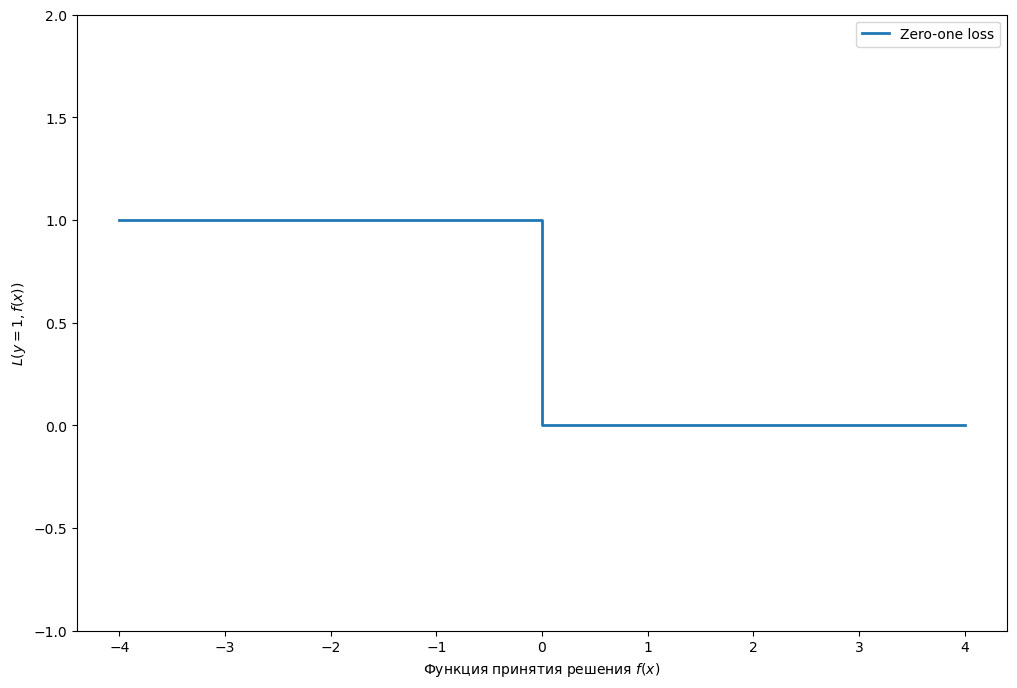

In [31]:
xmin, xmax = -4, 4
xx = np.linspace(xmin, xmax, 100)
lw = 2
plt.plot([xmin, 0, 0, xmax], [1,1,0,0], lw=lw, label='Zero-one loss')
# plt.plot(xx, np.log2(1 + np.exp(-xx)), color='green', lw=lw, label="Log loss")
plt.xlabel(r"Функция принятия решения $f(x)$")
plt.legend(loc="upper right")
plt.ylabel("$L(y=1, f(x))$")
plt.ylim((-1, 2));

In [32]:
from sklearn.metrics import zero_one_loss

print(y)
print(y_pred)
zero_one_loss([0,0,1,1], [0,0,0,1]) # средняя грубая ошибка (на сколько хороши наши предсказания)

[1 1 0 0 0 1 1 1 0 1 0 0 1 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0
 0 1 1 1 0 0 1 1 1 0 1 0 1 1 0 1 0 0 0 0 1 1 1 1 0 1 1 0 1 1 1 0 0 0 0 1 1
 1 1 0 0 1 1 1 1 0 1 1 0 1 1 1 0 0 1 1 0 1 1 0 0 1 0]
[-1.  1. -1. -1.  1. -1.  1. -1. -1. -1.]


0.25

## Переформулируем задачу
Вместо класса будем предсказывать вероятность принадлежности классу

$$\hat{p} = \sigma(x\theta) $$

где 

$$\sigma(t)=\frac{1}{1 + exp(-t)}$$

Пусть P вероятность принадлежности к классу. Тогда отношение шансов (odds ratio):


$$ OR = \frac{P} {1 - P} $$ <br>
$$ log {OR} \in R$$

Научились делать предсказание для $log {OR}$ с помощью линейной регрессии. Что делать теперь?

$$ log OR = x \theta$$

$$ P(y_i = 1 | x, \theta) = \frac {OR} {1 + OR} = \frac{e^{x\theta}} {1 + e^{x\theta}} = \sigma(x\theta) $$

$$ P(y_i = -1 | x, \theta) = ... = \sigma(-x\theta)$$

$$ P(y | x, \theta) = \prod_i {P(y = y_i | x_i, \theta)}$$


### Упражнение
упростите последнее выражение
- возьмем логарифм
- используем правило для логарифма произведения
- используем правило для логарифма частного

В результате должно получиться:
$ \log P(y | x, \theta) = -\sum {\log {(1 + e ^ {-y_i x \theta})}}$

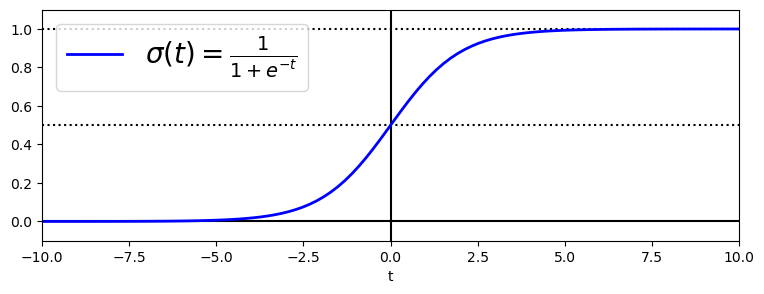

In [33]:
# Сигмоида
t = np.linspace(-10, 10, 100)
sig = 1 / (1 + np.exp(-t))
plt.figure(figsize=(9,3))
plt.plot([-10, 10], [0, 0], "k-")
plt.plot([-10, 10], [0.5, 0.5], "k:")
plt.plot([-10, 10], [1, 1], "k:")
plt.plot([0, 0], [-1.1, 1.1], "k-")
plt.plot(t, sig, "b-", linewidth=2, label=r"$\sigma(t) = \frac{1}{1 + e^{-t}}$")
plt.xlabel("t")
plt.legend(loc="upper left", fontsize=20)
plt.axis([-10, 10, -0.1, 1.1])
plt.show()

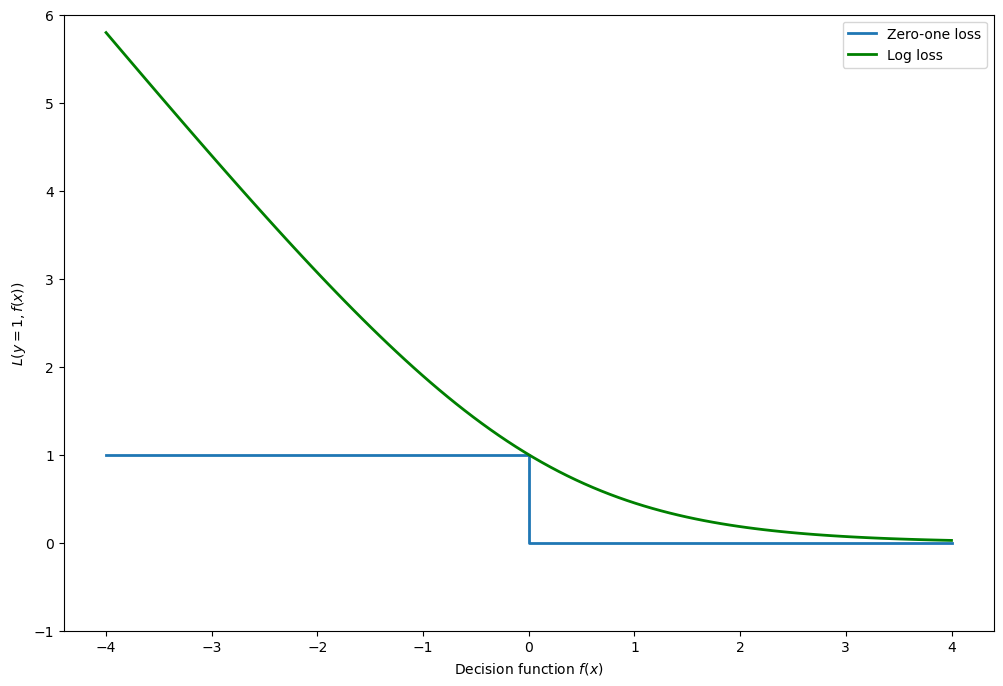

In [34]:
xmin, xmax = -4, 4
xx = np.linspace(xmin, xmax, 100)
lw = 2
plt.plot([xmin, 0, 0, xmax], [1, 1, 0, 0], lw=lw, label="Zero-one loss")
plt.plot(xx, np.log2(1 + np.exp(-xx)), color='green', lw=lw, label="Log loss")
plt.xlabel(r"Decision function $f(x)$")
plt.legend(loc="upper right")
plt.ylabel("$L(y=1, f(x))$")
plt.ylim((-1, 6));

# В sklearn

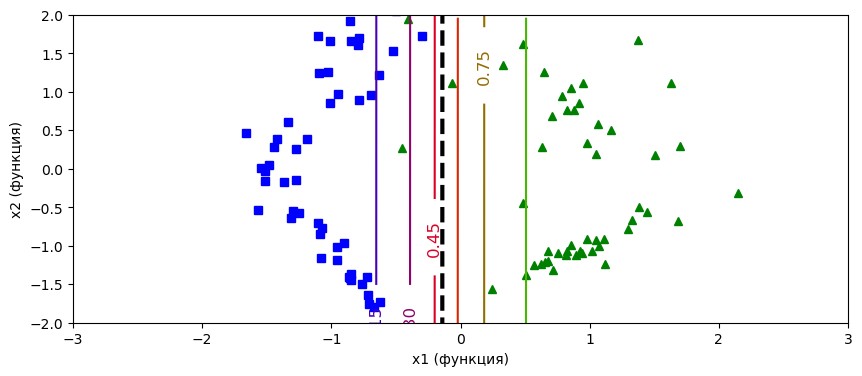

In [36]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(solver="lbfgs")
log_reg.fit(X, y)

x0, x1 = np.meshgrid(
    np.linspace(-2, 2, 500).reshape(-1, 1),
    np.linspace(-3, 3, 200).reshape(-1, 1)
)

X_new = np.c_[x0.ravel(), x1.ravel()]

y_proba = log_reg.predict_proba(X_new)

plt.figure(figsize=(10, 4))
plt.plot(X[y==0, 0], X[y==0, 1], "bs")
plt.plot(X[y==1, 0], X[y==1, 1], "g^")
zz = y_proba[:, 1].reshape(x0.shape)
contour = plt.contour(x0, x1, zz, cmap=plt.cm.brg)
left_right = np.array([-3, 3])
boundary = -(log_reg.coef_[0][0] * left_right + log_reg.intercept_[0]) / log_reg.coef_[0][1]
plt.clabel(contour, inline=1, fontsize=12)
plt.plot(left_right, boundary, "k--", linewidth=3)
plt.xlabel("x1 (функция)")
plt.ylabel("x2 (функция)")
plt.axis([-3, 3, -2, 2])
# plt.savefig("pics/descision.pdf")
plt.show()

## Регуляризация
- $L_1$
- $L_2$

К функционалу ошибки добавляем некоторый функционал от $\theta$:

$$Q + \lambda \theta ^ 2$$

Возьмем $C = \frac {1} {\lambda}$ и получим оптимизационную задачу:
$$ \theta = \arg min_{theta} {Q(x, y, \theta)} = C * Q(x, y, \theta) + \theta ^ 2$$


# Пример

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [40]:
def quality_report(prediction, actual):
    print("Accuracy: {:.3f}\nPrecission: {:.3f}\nRecall: {:.3f}\nf1_score: {:.3f}".format(
        accuracy_score(prediction, actual),
        precision_score(prediction, actual),
        recall_score(prediction, actual),
        f1_score(prediction, actual),
    ))

In [46]:
data = pd.read_csv("data/column_2C_weka.csv")

# перекручиваем целевую
data['class'] = data['class'].apply(lambda x: 1 if x=='Abnormal' else 0)

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    data.drop(['class'], axis=1), data['class'], test_size=0.20, random_state=42, stratify=data['class']
)

# стандартизируем
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Учим knn
knn = KNeighborsClassifier(n_neighbors=40)
knn.fit(X_train_scaled, y_train)

print("Train quality:")
quality_report(knn.predict(X_train_scaled), y_train)
print("Test quality:")
quality_report(knn.predict(X_test_scaled), y_test)

Train quality:
Accuracy: 0.835
Precission: 0.875
Recall: 0.880
f1_score: 0.878
Test quality:
Accuracy: 0.823
Precission: 0.905
Recall: 0.844
f1_score: 0.874


In [47]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()

log_reg.fit(X_train_scaled, y_train)
print("Train quality:")
quality_report(log_reg.predict(X_train_scaled), y_train)
print("Test quality:")
quality_report(log_reg.predict(X_test_scaled), y_test)

Train quality:
Accuracy: 0.847
Precission: 0.881
Recall: 0.892
f1_score: 0.886
Test quality:
Accuracy: 0.887
Precission: 0.929
Recall: 0.907
f1_score: 0.918


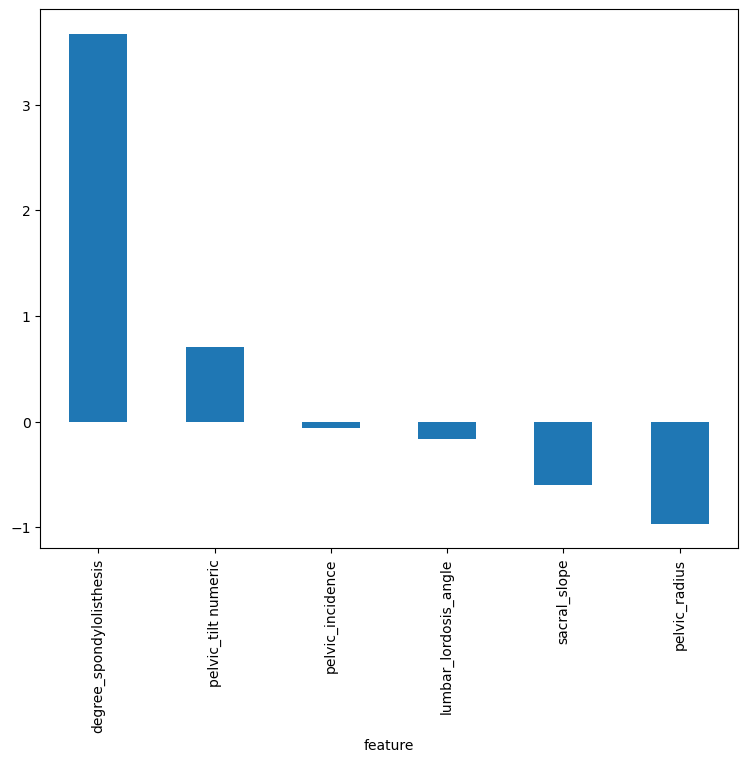

In [49]:
featureImportance = pd.DataFrame({"feature": data.drop('class', axis=1).columns,
                                  "importance": log_reg.coef_[0]})

featureImportance.set_index('feature', inplace=True)
featureImportance.sort_values(["importance"], ascending=False, inplace=True)
featureImportance["importance"].plot(kind="bar", figsize=(9, 7));